In [1]:
import sys
from pathlib import Path

# Find project root (folder containing 'src')
notebook_dir = Path().resolve()
project_root = notebook_dir
for parent in [notebook_dir] + list(notebook_dir.parents):
    if (parent / 'src').exists():
        project_root = parent
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"src exists: {(project_root / 'src').exists()}")
print(f"loader exists: {(project_root / 'src' / 'data' / 'loader.py').exists()}")

# Now imports will work
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.loader import get_connection, query

con = get_connection()
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
SAVE = '../outputs/figures/'
print("All imports ready!")

Project root: C:\Users\SUN\qcomm-market-basket-analysis
src exists: True
loader exists: True


IOException: IO Error: Cannot open file "C:\Users\SUN\qcomm-market-basket-analysis\data\processed\instacart.duckdb": The process cannot access the file because it is being used by another process.

File is already open in 
C:\Users\SUN\AppData\Local\Programs\Python\Python313\python.exe (PID 9468)

In [2]:
# Always start by understanding your schema
for table in ['orders','order_products_prior','products','aisles','departments']:
    df = query(f"SELECT * FROM {table} LIMIT 3", con)
    print(f"\n── {table} ({query(f'SELECT COUNT(*) FROM {table}', con).iloc[0,0]:,} rows) ──")
    display(df)


── orders (3,421,083 rows) ──


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,08,NaN
1,2398795,1,prior,2,3,07,15.0
2,473747,1,prior,3,3,12,21.0



── order_products_prior (32,434,489 rows) ──


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0



── products (49,688 rows) ──


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7



── aisles (134 rows) ──


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars



── departments (21 rows) ──


,department_id,department
0,1,frozen
1,2,other
2,3,bakery


C:\Users\SUN\AppData\Local\Temp\ipykernel_27188\3497752878.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\SUN\AppData\Local\Temp\ipykernel_27188\3497752878.py:28: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'{SAVE}01_basket_size_distribution.png', dpi=150, bbox_inches='tight')
C:\Users\SUN\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


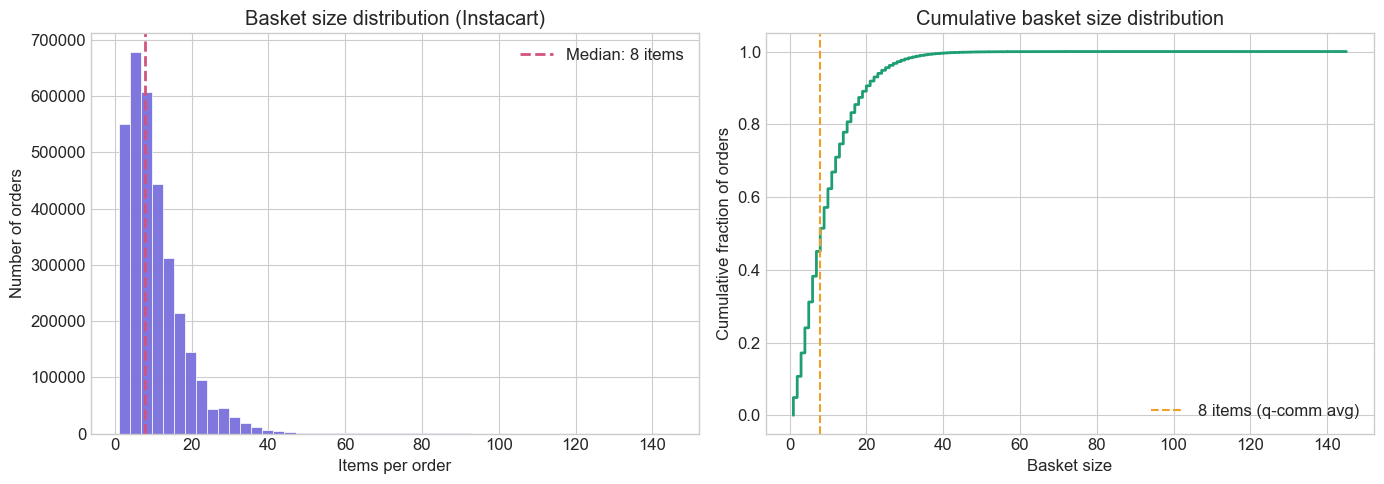

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: basket_size, dtype: float64


In [3]:
basket_sizes = query("""
    SELECT order_id, COUNT(*) AS basket_size
    FROM order_products_prior
    GROUP BY order_id
""", con)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(basket_sizes['basket_size'], bins=50, color='#7F77DD', edgecolor='white', linewidth=0.5)
axes[0].axvline(basket_sizes['basket_size'].median(), color='#D4537E', linestyle='--', linewidth=2,
                label=f"Median: {basket_sizes['basket_size'].median():.0f} items")
axes[0].set_xlabel('Items per order')
axes[0].set_ylabel('Number of orders')
axes[0].set_title('Basket size distribution (Instacart)')
axes[0].legend()

# Cumulative
sorted_sizes = basket_sizes['basket_size'].sort_values()
axes[1].plot(sorted_sizes.values, np.linspace(0, 1, len(sorted_sizes)), color='#1D9E75', linewidth=2)
axes[1].axvline(8, color='#EF9F27', linestyle='--', linewidth=1.5, label='8 items (q-comm avg)')
axes[1].set_xlabel('Basket size')
axes[1].set_ylabel('Cumulative fraction of orders')
axes[1].set_title('Cumulative basket size distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE}01_basket_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(basket_sizes['basket_size'].describe())

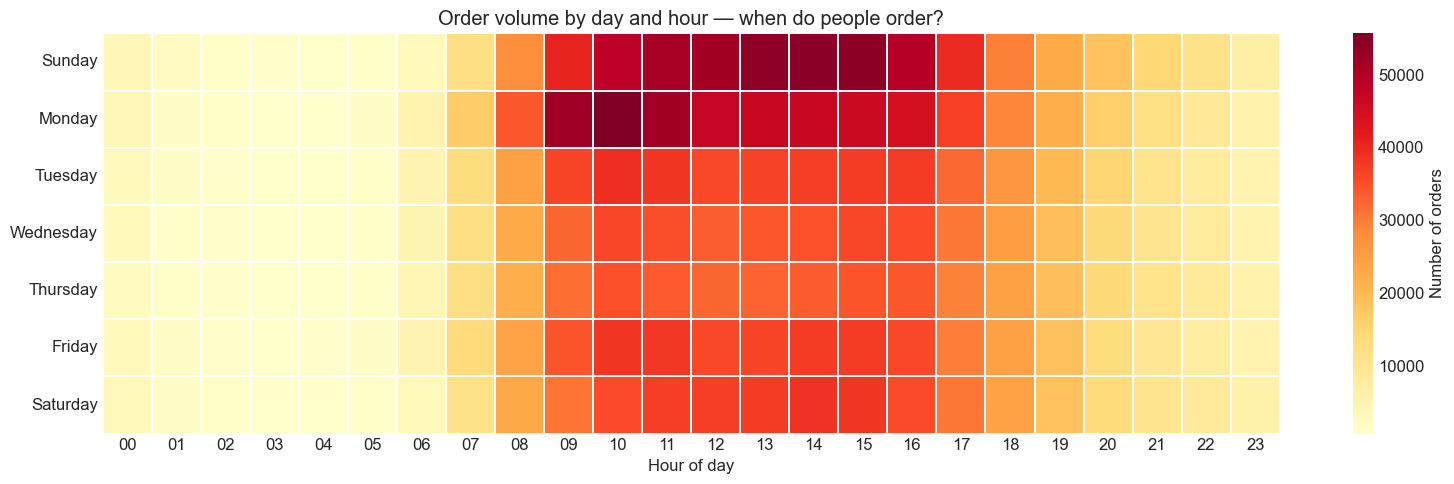

In [4]:
temporal = query("""
    SELECT 
        order_dow        AS day_of_week,
        order_hour_of_day AS hour,
        COUNT(*)         AS order_count
    FROM orders
    GROUP BY order_dow, order_hour_of_day
    ORDER BY order_dow, order_hour_of_day
""", con)

pivot = temporal.pivot(index='day_of_week', columns='hour', values='order_count')
pivot.index = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Number of orders'})
ax.set_title('Order volume by day and hour — when do people order?')
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'{SAVE}02_temporal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

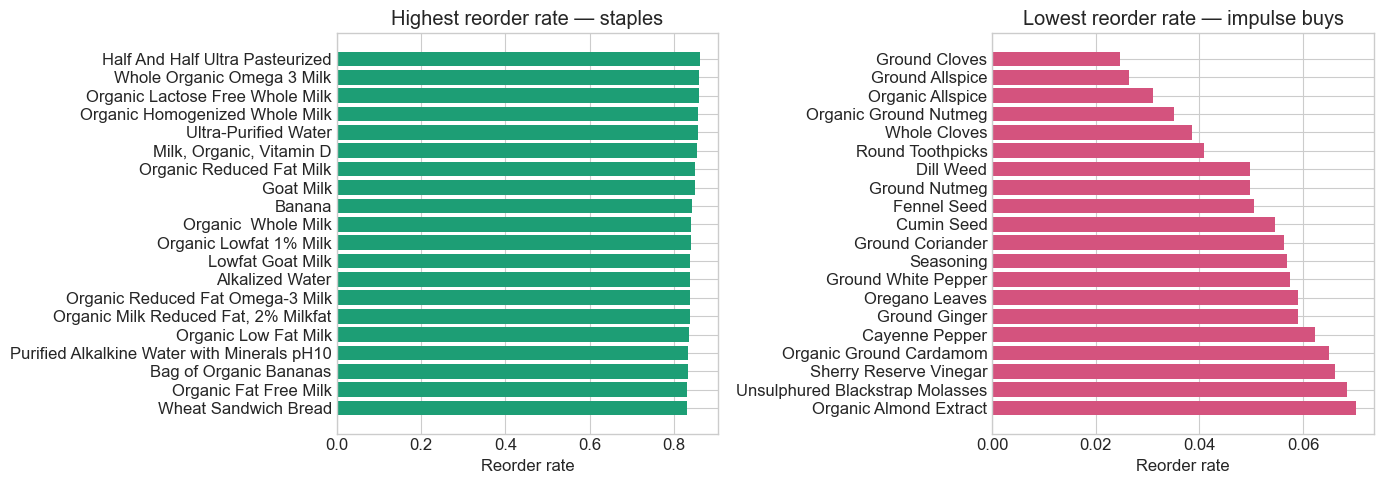

In [5]:
reorder = query("""
    SELECT 
        p.product_name,
        d.department,
        COUNT(*)              AS total_orders,
        AVG(op.reordered)     AS reorder_rate
    FROM order_products_prior op
    JOIN products p    USING (product_id)
    JOIN departments d USING (department_id)
    GROUP BY p.product_name, d.department
    HAVING COUNT(*) > 500
    ORDER BY reorder_rate DESC
""", con)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Highest reorder rate — these are staples
top_reorder = reorder.nlargest(20, 'reorder_rate')
axes[0].barh(top_reorder['product_name'][::-1], top_reorder['reorder_rate'][::-1], color='#1D9E75')
axes[0].set_title('Highest reorder rate — staples')
axes[0].set_xlabel('Reorder rate')

# Lowest reorder rate — these are impulse / one-time
low_reorder = reorder.nsmallest(20, 'reorder_rate')
axes[1].barh(low_reorder['product_name'][::-1], low_reorder['reorder_rate'][::-1], color='#D4537E')
axes[1].set_title('Lowest reorder rate — impulse buys')
axes[1].set_xlabel('Reorder rate')

plt.tight_layout()
plt.savefig(f'{SAVE}04_reorder_rate.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\SUN\AppData\Local\Temp\ipykernel_27188\793154536.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dept_share['department'], rotation=45, ha='right')


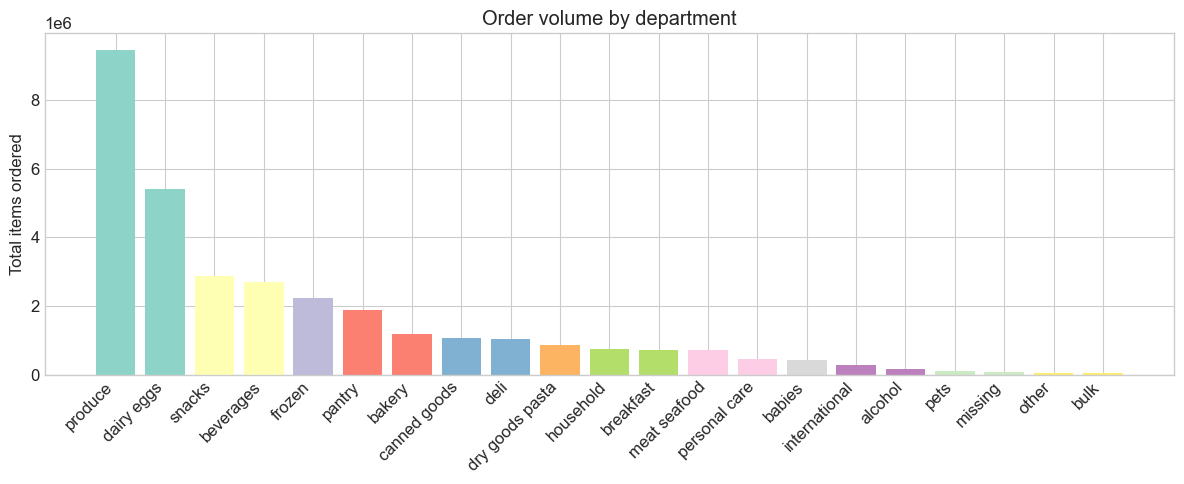

In [6]:
dept_share = query("""
    SELECT 
        d.department,
        COUNT(*) AS order_count
    FROM order_products_prior op
    JOIN products p    USING (product_id)
    JOIN departments d USING (department_id)
    GROUP BY d.department
    ORDER BY order_count DESC
""", con)

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Set3(np.linspace(0, 1, len(dept_share)))
bars = ax.bar(dept_share['department'], dept_share['order_count'], color=colors)
ax.set_xticklabels(dept_share['department'], rotation=45, ha='right')
ax.set_ylabel('Total items ordered')
ax.set_title('Order volume by department')
plt.tight_layout()
plt.savefig(f'{SAVE}05_department_share.png', dpi=150, bbox_inches='tight')
plt.show()

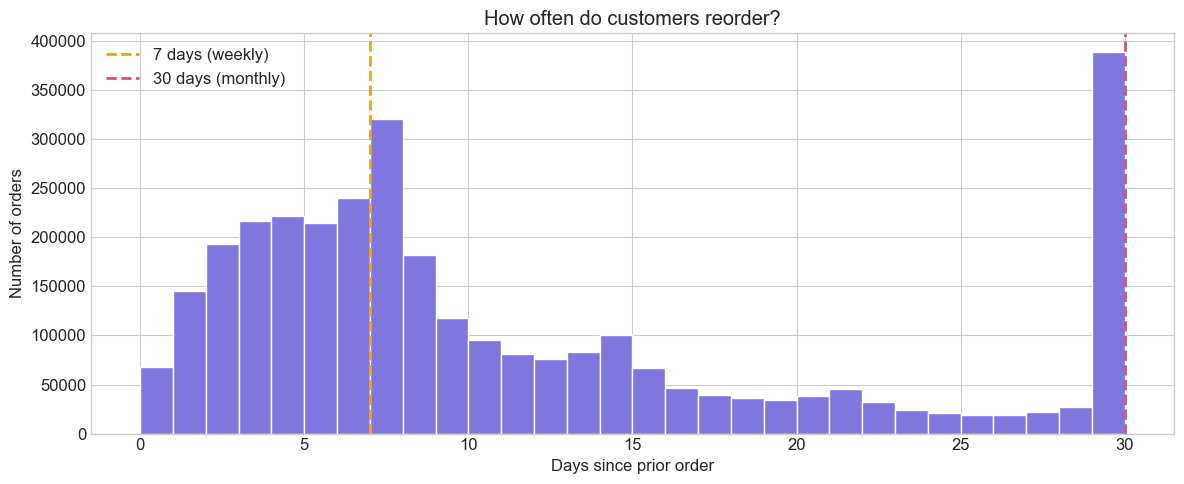

In [7]:
days_gap = query("""
    SELECT days_since_prior_order
    FROM orders
    WHERE days_since_prior_order IS NOT NULL
""", con)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(days_gap['days_since_prior_order'], bins=30, color='#7F77DD', edgecolor='white')
ax.axvline(7,  color='#EF9F27', linestyle='--', lw=2, label='7 days (weekly)')
ax.axvline(30, color='#D4537E', linestyle='--', lw=2, label='30 days (monthly)')
ax.set_xlabel('Days since prior order')
ax.set_ylabel('Number of orders')
ax.set_title('How often do customers reorder?')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE}06_days_since_prior.png', dpi=150, bbox_inches='tight')
plt.show()

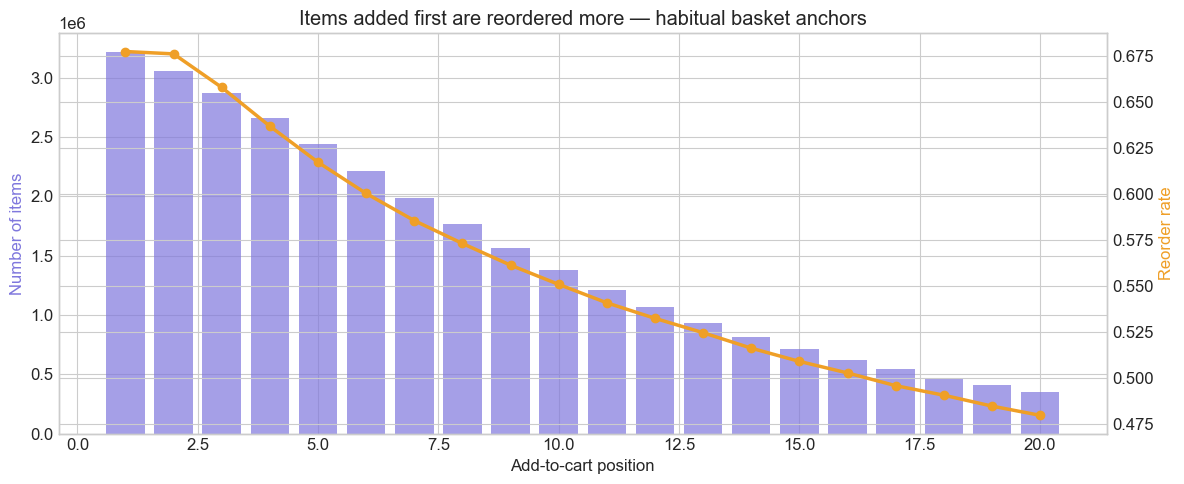

In [8]:
cart_order = query("""
    SELECT 
        add_to_cart_order AS cart_position,
        COUNT(*) AS frequency,
        AVG(reordered) AS reorder_rate
    FROM order_products_prior
    WHERE add_to_cart_order <= 20
    GROUP BY add_to_cart_order
    ORDER BY add_to_cart_order
""", con)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(cart_order['cart_position'], cart_order['frequency'], color='#7F77DD', alpha=0.7, label='Frequency')
ax2.plot(cart_order['cart_position'], cart_order['reorder_rate'], color='#EF9F27', linewidth=2.5, marker='o', label='Reorder rate')

ax1.set_xlabel('Add-to-cart position')
ax1.set_ylabel('Number of items', color='#7F77DD')
ax2.set_ylabel('Reorder rate', color='#EF9F27')
ax1.set_title('Items added first are reordered more — habitual basket anchors')
plt.tight_layout()
plt.savefig(f'{SAVE}07_cart_order_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

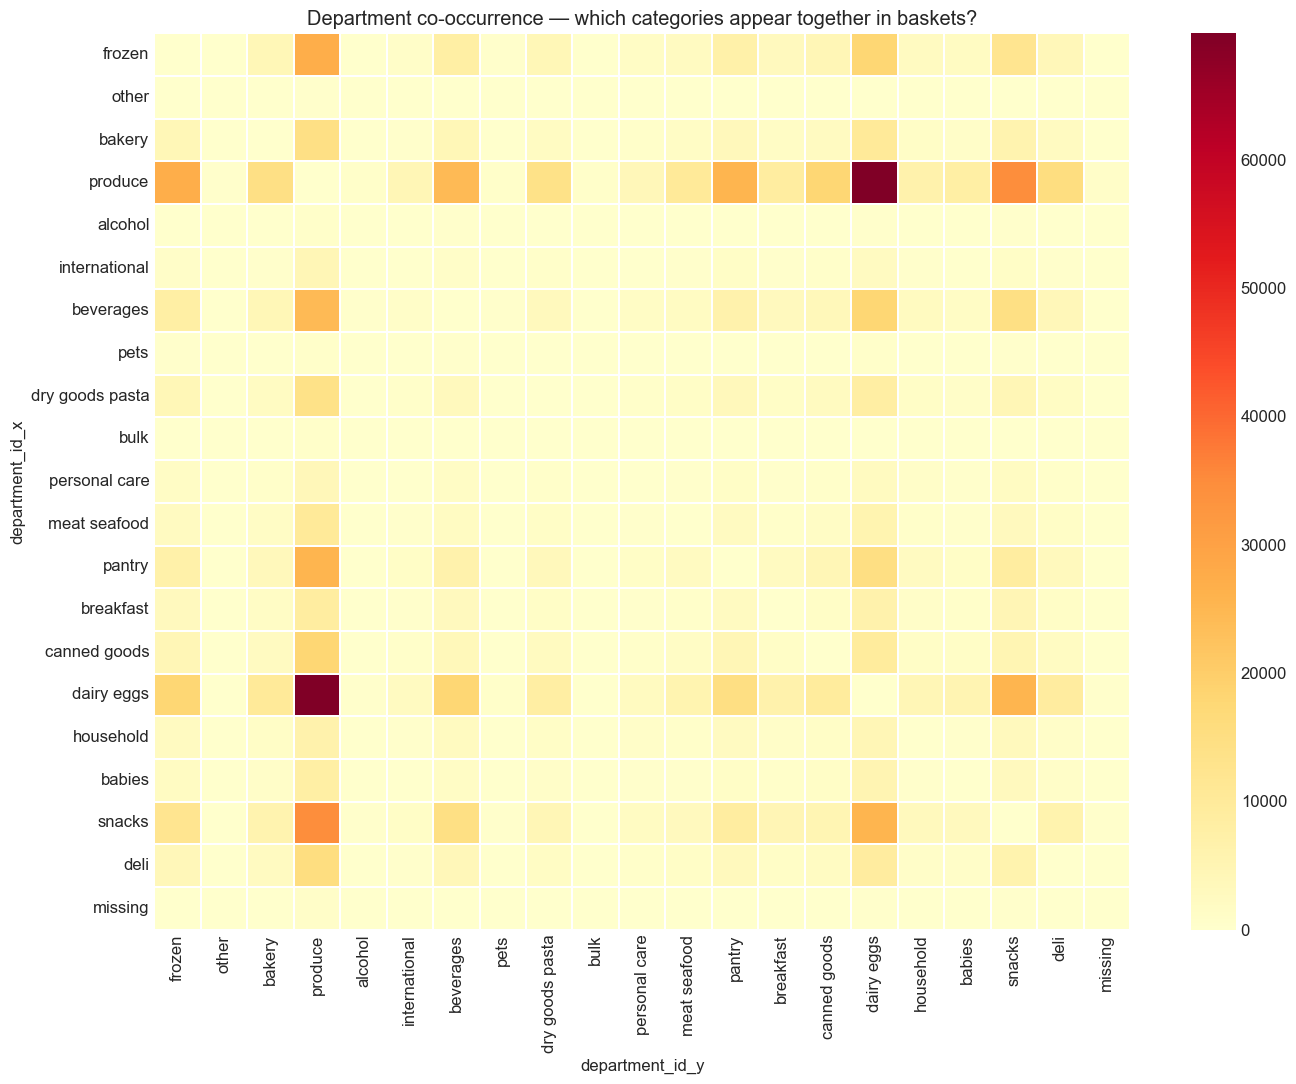

In [9]:
# Sample 5000 orders for speed — full MBA comes in Phase 2
sample_orders = query("""
    SELECT op.order_id, p.department_id
    FROM order_products_prior op
    JOIN products p USING (product_id)
    WHERE op.order_id IN (
        SELECT DISTINCT order_id 
        FROM order_products_prior 
        USING SAMPLE 5000
    )
""", con)

cooccurrence = (
    sample_orders
    .merge(sample_orders, on='order_id')
    .query('department_id_x != department_id_y')
    .groupby(['department_id_x','department_id_y'])
    .size()
    .unstack(fill_value=0)
)

dept_names = query("SELECT department_id, department FROM departments", con).set_index('department_id')['department']
cooccurrence.index   = cooccurrence.index.map(dept_names)
cooccurrence.columns = cooccurrence.columns.map(dept_names)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cooccurrence, cmap='YlOrRd', ax=ax, linewidths=0.2)
ax.set_title('Department co-occurrence — which categories appear together in baskets?')
plt.tight_layout()
plt.savefig(f'{SAVE}08_cooccurrence_teaser.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# This cell becomes your notebook conclusion — write findings as markdown

findings = query("""
    SELECT 
        ROUND(AVG(basket_size), 2) AS avg_basket_size,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY basket_size) AS median_basket_size,
        MAX(basket_size) AS max_basket_size
    FROM (
        SELECT order_id, COUNT(*) AS basket_size
        FROM order_products_prior
        GROUP BY order_id
    )
""", con)

reorder_overall = query("SELECT ROUND(AVG(reordered)*100, 1) AS pct_reordered FROM order_products_prior", con)
total_orders    = query("SELECT COUNT(DISTINCT order_id) AS n FROM order_products_prior", con)

print("=" * 50)
print("KEY EDA FINDINGS — Phase 1 Summary")
print("=" * 50)
print(f"Total orders analyzed:   {total_orders.iloc[0,0]:,}")
print(f"Average basket size:     {findings.iloc[0,0]} items")
print(f"Median basket size:      {findings.iloc[0,1]} items")
print(f"Max basket size:         {findings.iloc[0,2]} items")
print(f"Overall reorder rate:    {reorder_overall.iloc[0,0]}%")
print()
print("Insights:")
print("  • Produce & dairy dominate — high frequency, high reorder")
print("  • Strong weekly (7-day) ordering cycle detected")
print("  • First items added to cart are overwhelmingly staples")
print("  • Department co-occurrence reveals natural bundle candidates")

con.close()

KEY EDA FINDINGS — Phase 1 Summary
Total orders analyzed:   3,214,874
Average basket size:     10.09 items
Median basket size:      8.0 items
Max basket size:         145 items
Overall reorder rate:    59.0%

Insights:
  • Produce & dairy dominate — high frequency, high reorder
  • Strong weekly (7-day) ordering cycle detected
  • First items added to cart are overwhelmingly staples
  • Department co-occurrence reveals natural bundle candidates
